Loaded: AnnData object with n_obs × n_vars = 46720 × 28015
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_cells'
    uns: 'log

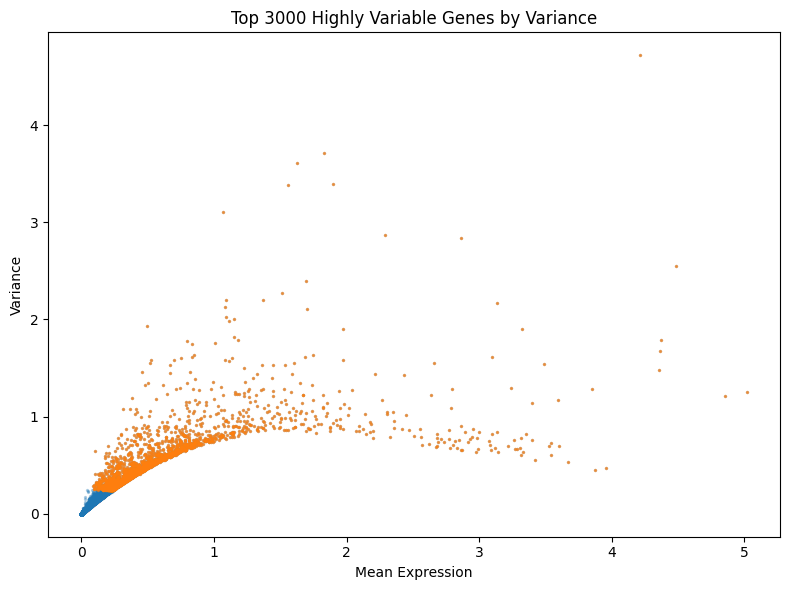

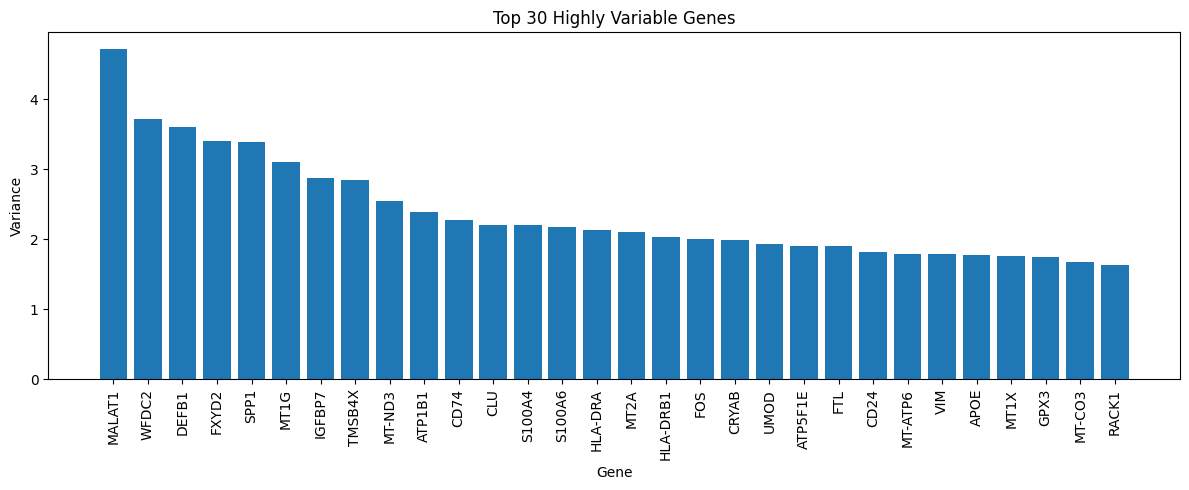

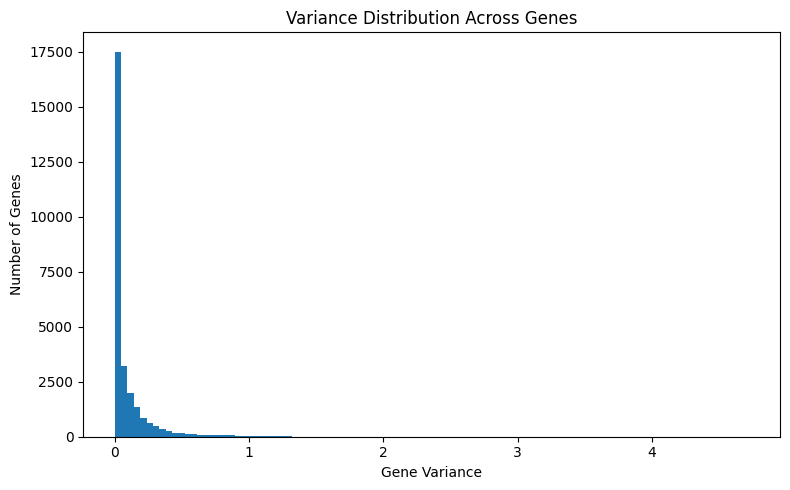


Saved:
- results/Top_3000_HVG_by_variance.csv
- results/GSE183276_HVG3000_by_variance.h5ad
- results/GSE183276_normalized_with_HVG3000_variance.h5ad


In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# ==============================
# Load normalized data
# ==============================

adata = sc.read_h5ad(RESULTS_DIR / "GSE183276_normalized.h5ad")

print("Loaded:", adata)

# ==============================
# Calculate variance per gene
# ==============================

X = adata.X

# sparse safe variance calculation
gene_mean = np.asarray(X.mean(axis=0)).ravel()
gene_mean_sq = np.asarray(X.power(2).mean(axis=0)).ravel()
gene_variance = gene_mean_sq - gene_mean**2

hvg_df = pd.DataFrame({
    "gene": adata.var_names,
    "mean_expression": gene_mean,
    "variance": gene_variance
})

# ==============================
# Select top 3000 genes by variance
# ==============================

hvg_df = hvg_df.sort_values("variance", ascending=False)

top3000 = hvg_df.head(3000).copy()
top3000["rank"] = range(1, len(top3000) + 1)

top3000.to_csv(
    RESULTS_DIR / "Top_3000_HVG_by_variance.csv",
    index=False
)

print("\nTop 20 HVGs by variance:")
print(top3000.head(20))

# ==============================
# Mark HVG in AnnData
# ==============================

adata.var["variance"] = gene_variance
adata.var["mean_expression"] = gene_mean
adata.var["highly_variable"] = adata.var_names.isin(top3000["gene"])

adata_hvg = adata[:, adata.var["highly_variable"]].copy()

print("\nHVG AnnData:", adata_hvg)

# ==============================
# Save HVG dataset
# ==============================

adata.write_h5ad(
    RESULTS_DIR / "GSE183276_normalized_with_HVG3000_variance.h5ad"
)

adata_hvg.write_h5ad(
    RESULTS_DIR / "GSE183276_HVG3000_by_variance.h5ad"
)

# ==============================
# Plot 1: Mean vs Variance
# ==============================

plt.figure(figsize=(8, 6))

plt.scatter(
    hvg_df["mean_expression"],
    hvg_df["variance"],
    s=2,
    alpha=0.3
)

plt.scatter(
    top3000["mean_expression"],
    top3000["variance"],
    s=2,
    alpha=0.6
)

plt.xlabel("Mean Expression")
plt.ylabel("Variance")
plt.title("Top 3000 Highly Variable Genes by Variance")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "HVG3000_mean_vs_variance.png",
    dpi=300
)
plt.show()

# ==============================
# Plot 2: Top 30 HVGs
# ==============================

top30 = top3000.head(30)

plt.figure(figsize=(12, 5))

plt.bar(
    top30["gene"],
    top30["variance"]
)

plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Variance")
plt.title("Top 30 Highly Variable Genes")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "HVG3000_top30_genes.png",
    dpi=300
)
plt.show()

# ==============================
# Plot 3: Variance distribution
# ==============================

plt.figure(figsize=(8, 5))

plt.hist(
    hvg_df["variance"],
    bins=100
)

plt.xlabel("Gene Variance")
plt.ylabel("Number of Genes")
plt.title("Variance Distribution Across Genes")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "HVG3000_variance_distribution.png",
    dpi=300
)
plt.show()

print("\nSaved:")
print("- results/Top_3000_HVG_by_variance.csv")
print("- results/GSE183276_HVG3000_by_variance.h5ad")
print("- results/GSE183276_normalized_with_HVG3000_variance.h5ad")

HVG Dataset Overview

In [2]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")

# ====================================
# Load HVG dataset
# ====================================

adata = sc.read_h5ad(
    RESULTS_DIR / "GSE183276_HVG3000_by_variance.h5ad"
)

print("===== HVG DATASET =====")
print(adata)

print("\n===== Shape =====")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\n===== Layers =====")
print(list(adata.layers.keys()))

print("\n===== obs columns =====")
print(list(adata.obs.columns))

print("\n===== var columns =====")
print(list(adata.var.columns))

===== HVG DATASET =====
AnnData object with n_obs × n_vars = 46720 × 3000
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'
    var: 'n_cells

In [11]:
#First 10×10 expression matrix
small = adata.X[:10, :10]

if hasattr(small, "toarray"):
    small = small.toarray()

df = pd.DataFrame(
    small,
    index=adata.obs_names[:10],
    columns=adata.var_names[:10]
)

print(df)

                                    A2M      AAK1     AAMDC      AAMP  \
AKI3010018_AAACCCACAGGGATAC-1  0.000000  0.000000  1.657489  0.000000   
AKI3010018_AAACCCATCTGATGGT-1  1.257387  0.000000  0.000000  2.077180   
AKI3010018_AAACGAATCTCCAATT-1  0.000000  0.000000  0.000000  0.000000   
AKI3010018_AAACGAATCTTTCCAA-1  0.000000  0.000000  1.460567  0.000000   
AKI3010018_AAACGCTAGCTTTCTT-1  0.000000  2.238391  0.000000  0.000000   
AKI3010018_AAACGCTGTCACCGAC-1  0.000000  0.000000  0.000000  0.000000   
AKI3010018_AAACGCTGTTAGAAAC-1  0.000000  0.000000  0.000000  0.000000   
AKI3010018_AAACGCTTCCACGTCT-1  0.000000  0.000000  1.188693  0.751729   
AKI3010018_AAACGCTTCGATACGT-1  0.000000  0.000000  0.609247  0.341190   
AKI3010018_AAAGAACCAAGAGTAT-1  0.000000  0.000000  0.000000  0.000000   

                                  ABCB1     ABCD3   ABHD14A   ABHD14B  \
AKI3010018_AAACCCACAGGGATAC-1  0.000000  1.675664  0.000000  0.000000   
AKI3010018_AAACCCATCTGATGGT-1  0.000000  0.000000 

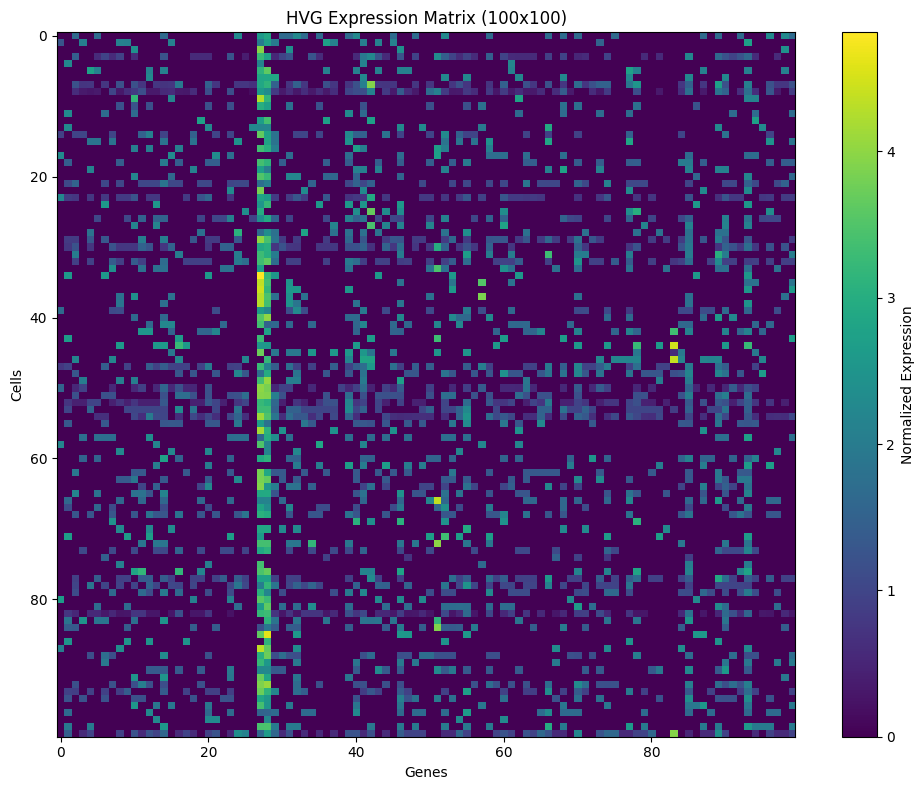

In [4]:
# ====================================
# Small matrix visualization
# ====================================

small = adata.X[:100, :100]

if hasattr(small, "toarray"):
    small = small.toarray()

plt.figure(figsize=(10,8))

plt.imshow(
    small,
    aspect="auto"
)

plt.colorbar(label="Normalized Expression")

plt.xlabel("Genes")
plt.ylabel("Cells")

plt.title("HVG Expression Matrix (100x100)")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "HVG_matrix_100x100.png",
    dpi=300
)

plt.show()

In [5]:
# ====================================
# Sparsity
# ====================================

nonzero = adata.X.nnz

total = adata.n_obs * adata.n_vars

sparsity = 100 * (1 - nonzero / total)

print("\n===== Sparsity =====")
print(f"{sparsity:.2f}% sparse")


===== Sparsity =====
65.43% sparse


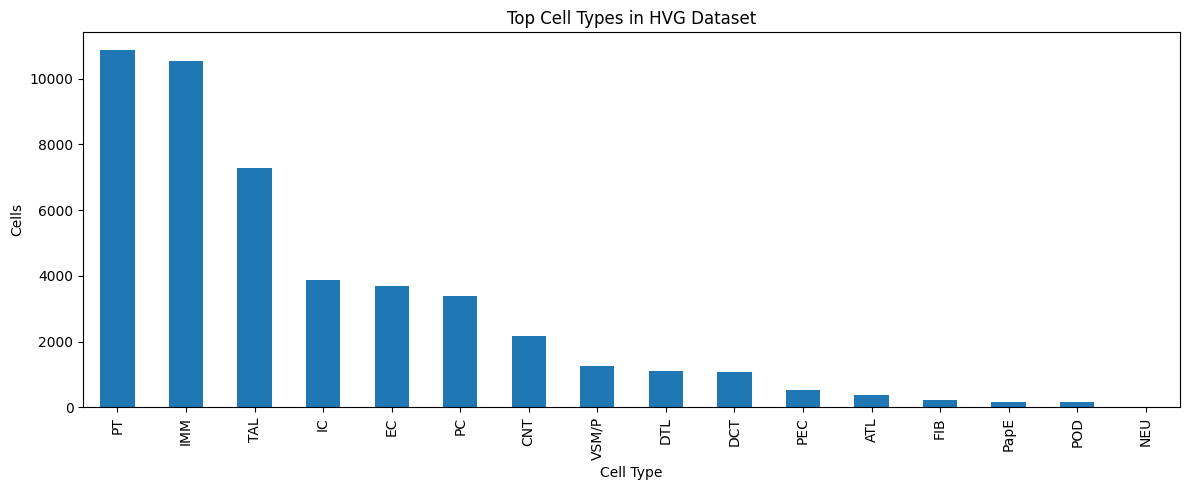

In [6]:
# ====================================
# Cell types
# ====================================

if "subclass.l1" in adata.obs.columns:

    plt.figure(figsize=(12,5))

    adata.obs["subclass.l1"] \
        .value_counts() \
        .head(20) \
        .plot(kind="bar")

    plt.xlabel("Cell Type")
    plt.ylabel("Cells")

    plt.title("Top Cell Types in HVG Dataset")

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / "HVG_top_celltypes.png",
        dpi=300
    )

    plt.show()

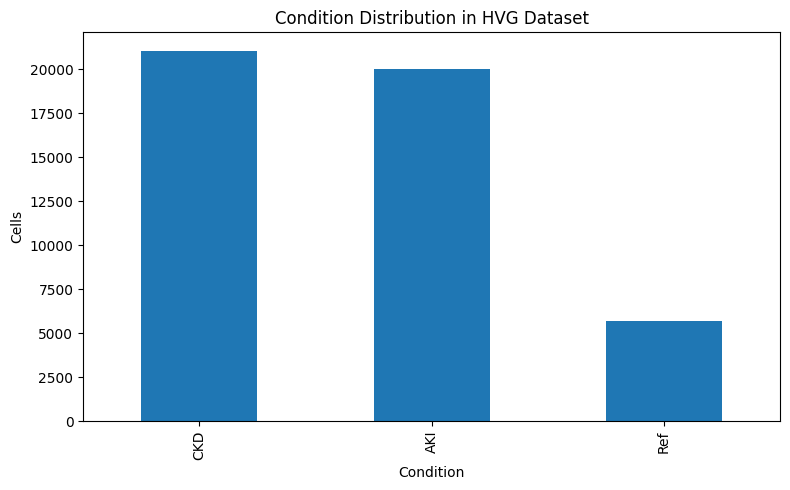

In [7]:
# ====================================
# Disease distribution
# ====================================

if "condition.l1" in adata.obs.columns:

    plt.figure(figsize=(8,5))

    adata.obs["condition.l1"] \
        .value_counts() \
        .plot(kind="bar")

    plt.xlabel("Condition")
    plt.ylabel("Cells")

    plt.title("Condition Distribution in HVG Dataset")

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / "HVG_condition_distribution.png",
        dpi=300
    )

    plt.show()


===== Top Expressed HVGs =====
         gene     expression
2946   MT-CO1  234489.940769
2947   MT-CO2  226950.358358
2951   MT-ND3  209401.008608
2949  MT-ATP6  204290.467668
2950   MT-CO3  203768.502524
2953   MT-ND4  203426.186919
1344   MALAT1  196826.589967
2141    RPL41  184902.063436
745    EEF1A1  181096.413697
2956   MT-CYB  179931.463801
2150    RPLP1  171598.751229
2102    RPL10  168186.059360
2945   MT-ND2  168096.170709
2156    RPS12  165635.807134
2106    RPL13  165445.406362
2163    RPS18  164633.706665
236       B2M  163110.663880
2176    RPS28  159954.969135
905      FTH1  158700.878023
2668     TPT1  158690.223681


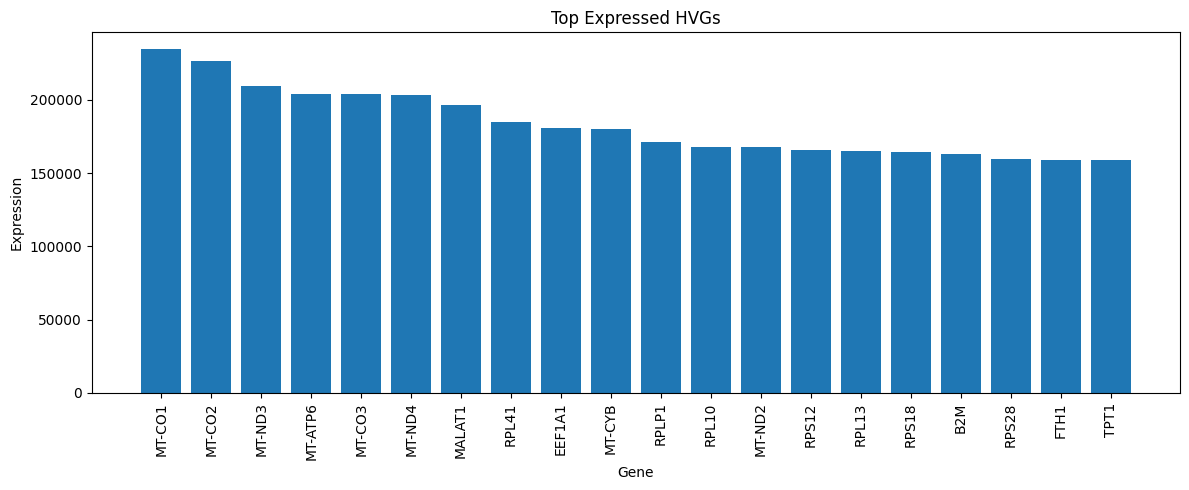

In [8]:
# ====================================
# Top expressed HVGs
# ====================================

gene_sum = np.asarray(
    adata.X.sum(axis=0)
).ravel()

gene_df = pd.DataFrame({
    "gene": adata.var_names,
    "expression": gene_sum
})

gene_df = gene_df.sort_values(
    "expression",
    ascending=False
)

print("\n===== Top Expressed HVGs =====")
print(gene_df.head(20))

top20 = gene_df.head(20)

plt.figure(figsize=(12,5))

plt.bar(
    top20["gene"],
    top20["expression"]
)

plt.xticks(rotation=90)

plt.xlabel("Gene")
plt.ylabel("Expression")

plt.title("Top Expressed HVGs")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "Top_Expressed_HVGs.png",
    dpi=300
)

plt.show()

In [3]:
# ====================================
# Expression matrix summary
# ====================================

X = adata.X

if hasattr(X, "toarray"):
    vals = X.toarray().flatten()
else:
    vals = X.flatten()

vals = vals[vals > 0]

print("\n===== Expression Summary =====")
print(pd.Series(vals).describe())


===== Expression Summary =====
count    4.840405e+07
mean     1.608623e+00
std      8.505903e-01
min      3.613075e-05
25%      9.930311e-01
50%      1.447397e+00
75%      2.024329e+00
max      9.092773e+00
dtype: float64
